In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
data = pd.read_csv("/content/datafile (1).csv")

In [3]:
data.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [4]:
data.tail()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
44,SUGARCANE,Tamil Nadu,66335.06,89025.27,85.79,1015.45
45,WHEAT,Madhya Pradesh,12464.40,22489.75,810.25,23.59
46,WHEAT,Punjab,17945.58,35423.48,804.80,39.83
47,WHEAT,Uttar Pradesh,18979.38,31902.74,769.84,34.99
48,WHEAT,Rajasthan,19119.08,29876.36,683.58,37.19


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Crop                                   49 non-null     object 
 1   State                                  49 non-null     object 
 2   Cost of Cultivation (`/Hectare) A2+FL  49 non-null     float64
 3   Cost of Cultivation (`/Hectare) C2     49 non-null     float64
 4   Cost of Production (`/Quintal) C2      49 non-null     float64
 5   Yield (Quintal/ Hectare)               49 non-null     float64
dtypes: float64(4), object(2)
memory usage: 2.4+ KB


In [6]:
data.shape

(49, 6)

In [7]:
data.describe()

,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
count,49.000000,49.000000,49.000000,49.000000
mean,20363.537347,31364.666735,1620.537755,98.086735
std,13561.435306,20095.783569,1104.990472,245.293123
min,5483.540000,7868.640000,85.790000,1.320000
25%,12774.410000,19259.840000,732.620000,9.590000
50%,17022.000000,25909.050000,1595.560000,13.700000
75%,24731.060000,35423.480000,2228.970000,36.610000
max,66335.060000,91442.630000,5777.480000,1015.450000


In [8]:
data.isnull().sum()

,0
Crop,0
State,0
Cost of Cultivation (`/Hectare) A2+FL,0
Cost of Cultivation (`/Hectare) C2,0
Cost of Production (`/Quintal) C2,0
Yield (Quintal/ Hectare),0


In [9]:
data.duplicated().sum()

np.int64(0)

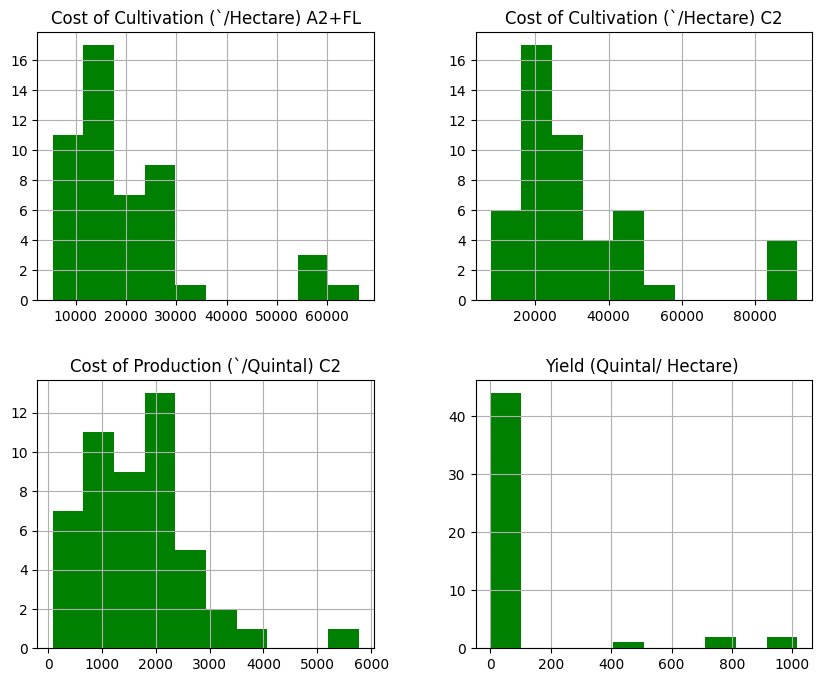

In [10]:
data.hist(figsize=(10,8),color="green")
plt.show()

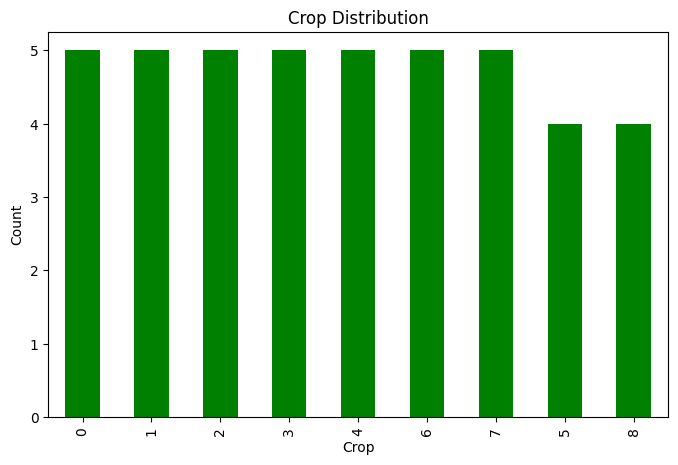

In [43]:
data["Crop"].value_counts().plot(
    kind="bar",
    color="green",
    figsize=(8,5)
)

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show()

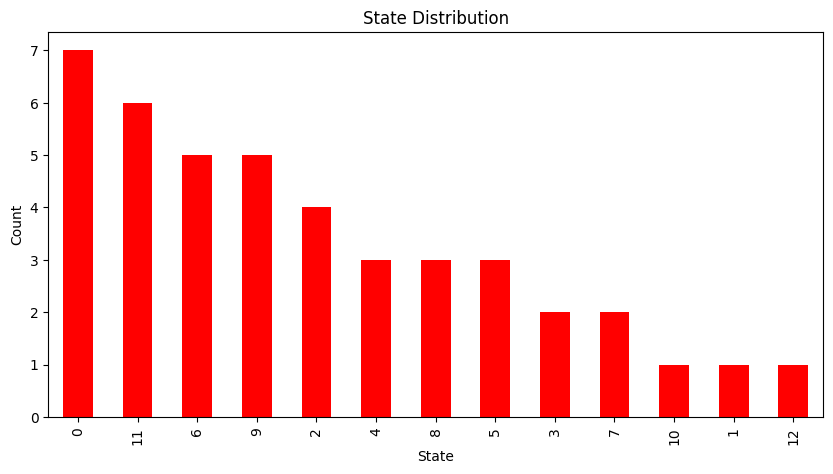

In [46]:
data["State"].value_counts().plot(
    kind="bar",
    color="red",
    figsize=(10,5)
)

plt.title("State Distribution")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

In [32]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

<Axes: >

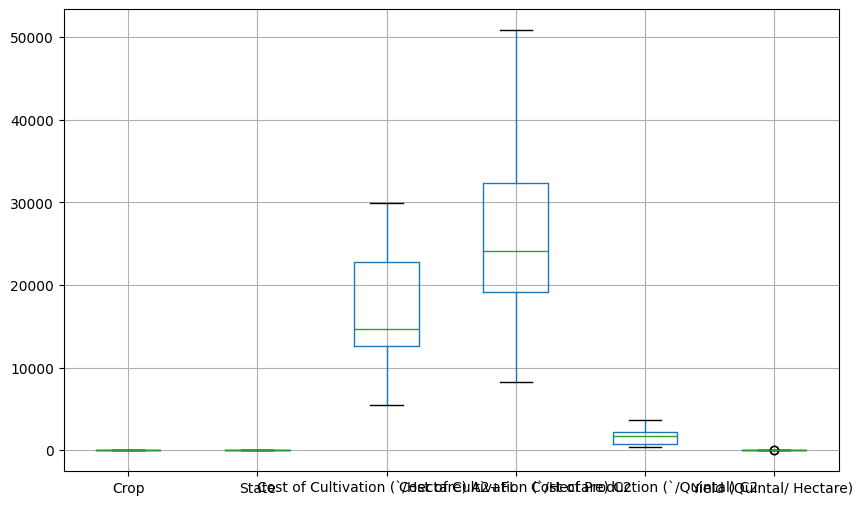

In [41]:
data.boxplot(figsize=(10,6))

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data["Crop"] = le.fit_transform(data["Crop"])

data["State"] = le.fit_transform(data["State"])

In [34]:
X = data.drop("Yield (Quintal/ Hectare) ", axis=1)

y = data["Yield (Quintal/ Hectare) "]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
X_train

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2
3,0,0,17051.66,24171.65,3670.54
6,1,8,29047.10,50828.83,2003.76
28,5,0,6684.18,13209.32,2228.97
32,6,12,24731.06,33046.12,731.25
19,3,6,26078.66,32683.46,3207.35
17,3,10,22507.86,30393.66,2358.00
13,2,6,12985.95,18679.33,2277.68
46,8,8,17945.58,35423.48,804.80
15,3,4,13647.10,17314.20,3484.01
9,1,3,29918.97,44018.18,2127.35


In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [38]:
y_pred = model.predict(X_test)

In [39]:
print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))

MAE: 5.934252014992069
MSE: 44.90846137404369


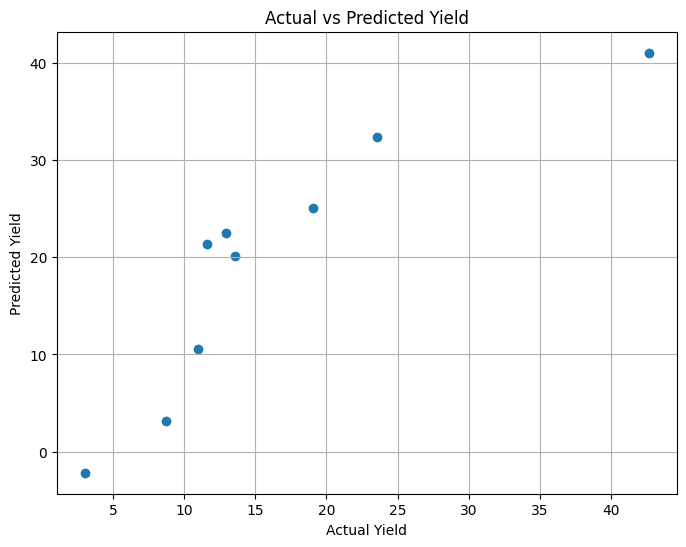

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.grid(True)
plt.show()